In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Población total
N = 100000

# Condiciones iniciales
S0 = 99999
I0 = 1
R0 = 0

# Parámetros
beta = 0.4   # tasa de transmisión
gamma = 0.1  # tasa de recuperación

# Tiempo 180 días
dias = 180
t = np.linspace(0, dias, dias)

In [21]:
def SIR_model(S0, I0, R0, beta, gamma, N, dias):
    S = np.zeros(dias)
    I = np.zeros(dias)
    R = np.zeros(dias)

    # valores iniciales
    S[0] = S0
    I[0] = I0
    R[0] = R0

    for i in range(1, dias):
        dS = -beta * S[i-1] * I[i-1] / N
        dI = beta * S[i-1] * I[i-1] / N - gamma * I[i-1]
        dR = gamma * I[i-1]

        S[i] = S[i-1] + dS
        I[i] = I[i-1] + dI
        R[i] = R[i-1] + dR

    return S, I, R

S, I, R = SIR_model(S0, I0, R0, beta, gamma, N, dias)

In [22]:
#¿Cuándo se alcanzará el número máximo de infectados en la ciudad?
dia_pico = np.argmax(I)
dia_pico

np.int64(47)

In [23]:
#¿Cuántas personas estarán infectadas en el peor momento del brote?
max_infectados = max(I)
max_infectados

np.float64(42398.84778814374)

In [24]:
#¿Cuánto tiempo tardará la epidemia en desaparecer?
for i in range(len(I)):
    if I[i] < 1:
        print("Día en que desaparece:", i)
        break

Día en que desaparece: 162


In [25]:
#¿Qué porcentaje de la población se habrá infectado al final de la epidemia?
porcentaje = (R[-1] / N) * 100
porcentaje

np.float64(98.45983276997839)

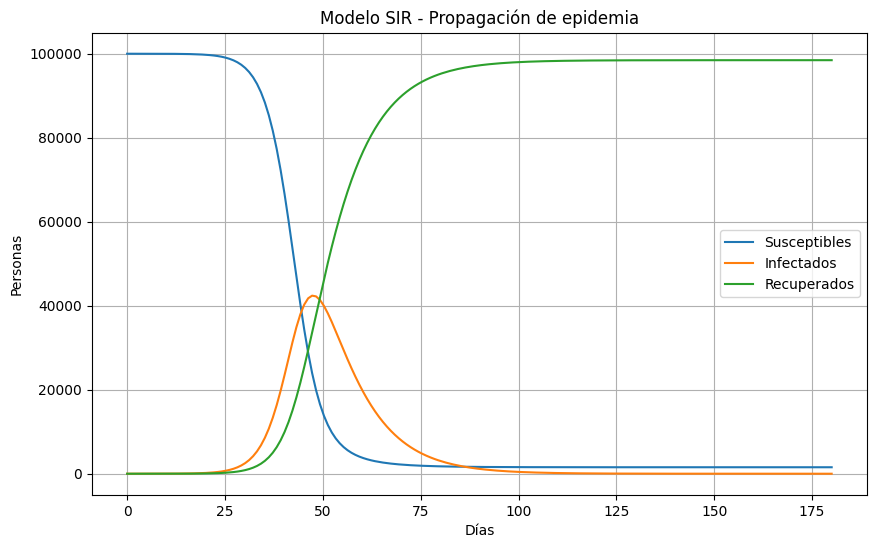

In [26]:
plt.figure(figsize=(10,6))
plt.plot(t, S, label='Susceptibles')
plt.plot(t, I, label='Infectados')
plt.plot(t, R, label='Recuperados')

plt.xlabel('Días')
plt.ylabel('Personas')
plt.title('Modelo SIR - Propagación de epidemia')
plt.legend()
plt.grid()

plt.show()

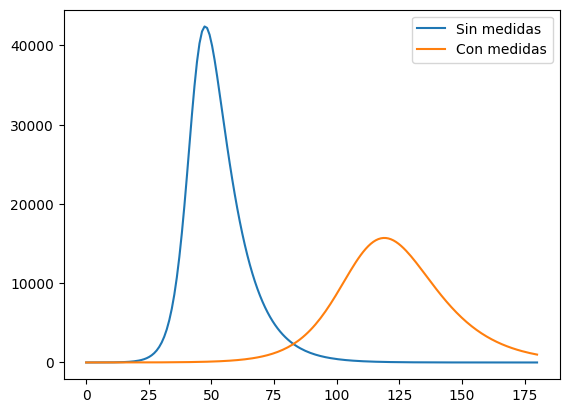

In [27]:
#¿Cómo cambiaría la propagación si se implementaran medidas como cuarentena o vacunación?
beta_nuevo = 0.2  # reducción por medidas
S2, I2, R2 = SIR_model(S0, I0, R0, beta_nuevo, gamma, N, dias)

plt.plot(t, I, label='Sin medidas')
plt.plot(t, I2, label='Con medidas')
plt.legend()
plt.show()